# Signal Injection Test

To assess the sensitivity of our search algorithm, we injected artificial laser-like Gaussian spikes into spectral data from HARPS.  We started with single HARPS observations of 20 stars, of spectral types F,G,K and M, at distances between 3 and 170 parsecs.  For each of these, we added an artificial Gaussian spike at a random wavelength, with a FWHM equal to the HARPS spectral resolution at that wavelength, and a peak flux corresponding to a random laser power between 500 W and 10 MW and a nominal transmitter aperture of 10 meters.  We then checked to see if our search algorithm recovered this artificial signal.  We repeated this process 100 times each for random laser powers in the bins (500 W-1 kW), (1 kW-10 kW),(10 kW-100 kW),(100 kW-1 MW),(1 MW-10 MW).

# Signal Injection Test: Results

Our results are as follows:

In [178]:
%matplotlib widget
from astropy.table import QTable
import astropy.units as u
import numpy as np
from pathlib import Path

In [179]:
detected_infile = "HARPSNewAlgoInjectionDetectedLasersFWHM5.txt"
nondetected_infile = "HARPSNewAlgoNullLasersFWHM5.txt"
figure_directory = Path("../manuscript-figures")

In [180]:
detected_t = QTable.read(detected_infile,format='pandas.csv',
                           names=['star','startype','dist','injected_wavelength','power','aperture',
                                  'detected_wavelength','filename']
)

nondetected_t = QTable.read(nondetected_infile,format='pandas.csv',
                           names=['star','startype','dist','injected_wavelength','power','aperture',
                                  'filename']
)


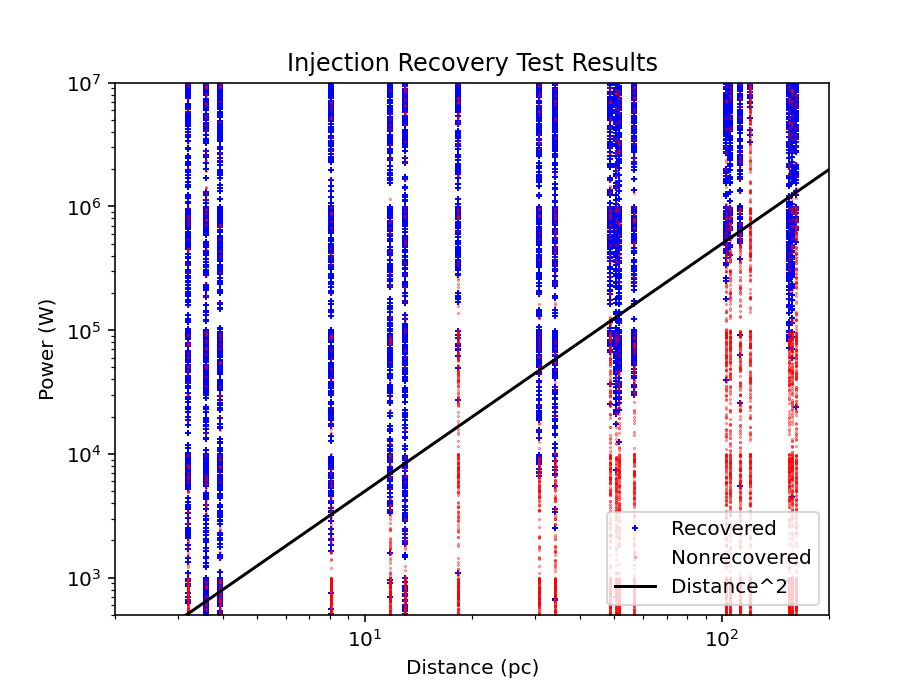

In [181]:
import matplotlib.pyplot as plt
plt.figure(1)
plt.clf()
plt.loglog(detected_t['dist'],detected_t['power'],'b+',markersize=3,linewidth=.1)
plt.loglog(nondetected_t['dist'],nondetected_t['power'],'r.',markersize=.5,linewidth=.1)
x = 2*np.logspace(0,2,50)
y = 50*x**2
plt.plot(x,y,'k-')
plt.axis([2,200,5e2,1e7])
plt.legend(('Recovered','Nonrecovered','Distance^2'),loc="lower right")
plt.title('Injection Recovery Test Results')
plt.xlabel('Distance (pc)')
plt.ylabel('Power (W)')
plt.show()
plt.savefig(figure_directory/"injection_recovery.pdf",format="pdf")


We see that the vast majority of artificial injected signals are recovered by our search algorithm at high laser power or short distances.  As expected, injected signals with low amplitude (large distance, small power) are difficult to detect.  Interestingly the detection threshold is not far from an inverse square law, indicating that the amplitude of the signal itself, not its contrast against the background star, is most important.

In [182]:
# Find percentage recovery rate in power/distance bins.

# Bin boundaries
power_boundaries = [500,1e3,1e4,1e5,1e6,1e7] 
distance_boundaries = [2,10,20,100,200] 
n_power_bins = len(power_boundaries[1:])
n_distance_bins = len(distance_boundaries[1:])

# Initialize array
percent_detected = np.full((n_power_bins,n_distance_bins),0.0)

# Loop over all bins                           
for i in range(n_power_bins):
    for j in range(n_distance_bins):
        n_detected = [(row['power']>power_boundaries[i]) and (row['power' ]<power_boundaries[i+1])
                      and (row['dist']>distance_boundaries[j]) and (row['dist']<distance_boundaries[j+1])
                      for row in detected_t].count(True)
        n_nondetected = [(row['power']>power_boundaries[i]) and (row['power' ]<power_boundaries[i+1])
                      and (row['dist']>distance_boundaries[j]) and (row['dist']<distance_boundaries[j+1])
                      for row in nondetected_t].count(True)
        percent_detected[i,j] = 100*n_detected/(n_detected+n_nondetected)

In [183]:
with np.printoptions(precision=1,suppress=True):
    print(percent_detected)

[[42.1  8.3  0.5  0.1]
 [78.5 45.   5.2  0.3]
 [84.2 64.7 64.7  3. ]
 [89.  86.7 83.2 43.9]
 [88.  85.  86.  76.3]]


|            | 2-10 pc| 10-20 pc | 20-100 pc| 100-200 pc |
|------------| ------ | -------- | -------- | ---------- |
|1 MW - 10 MW| 88%    | 85%      | 86%      | 76.3%      |
|100 kW-1 MW | 89%    | 86.7%    | 83.2%    | 43.9%      |
|10 kW-100 kW| 84.2%  | 64.7%    | 64.7%    | 3%         |
|1 kW-10 kW  | 78.5%  | 45%      | 5.2%     | 0.3%       |
|500 W-1 kW  | 42.1%  | 8.3%     | 0.5%     | 0.1%       |

Quantitatively, we see that we can detect injected signals with simulated powers of under a kilowatt at under 10 parsecs, with a recovery rate of almost 90%.  Lasers 100 parsecs or more away would need to be over 1 MW of brightness to be detectable.  

The recovery rate showed no obvious dependence on the spectral category (F,G,K,M) of the background star.

(28,)


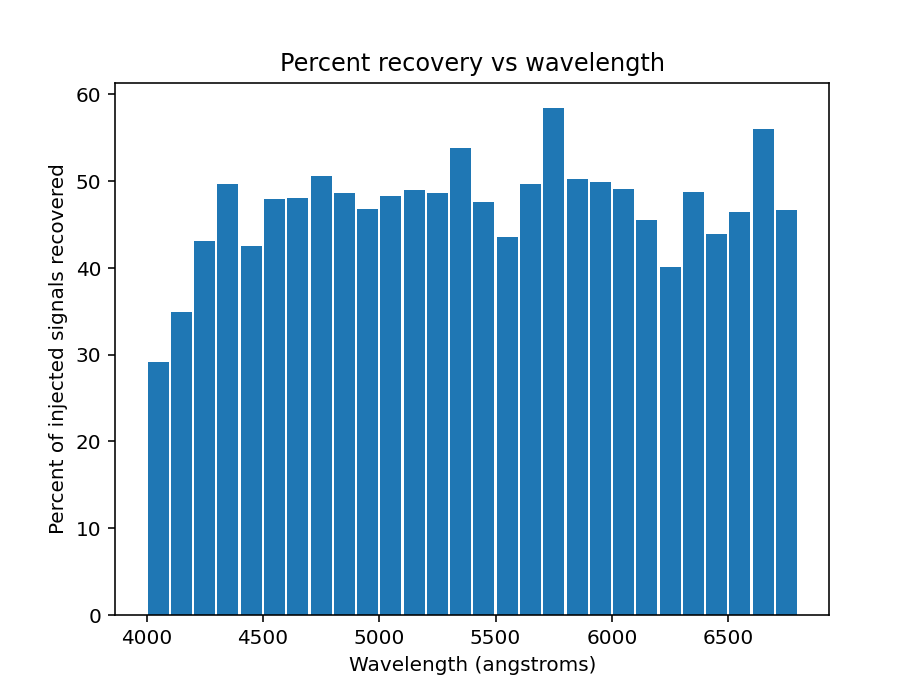

In [184]:
# Wavelength bins

wavel_boundaries = np.arange(4000,6900,100)
n_wavel_bins = len(wavel_boundaries[1:])
percent_recovery = np.zeros(n_wavel_bins)
n_samples = np.zeros(n_wavel_bins)
print(percent_recovery.shape)
for i in range(n_wavel_bins):
        n_detected = [(row['injected_wavelength']>wavel_boundaries[i]) and 
                      (row['injected_wavelength' ]<wavel_boundaries[i+1])
                      for row in detected_t].count(True)
        n_nondetected = [(row['injected_wavelength']>wavel_boundaries[i]) and 
                      (row['injected_wavelength' ]<wavel_boundaries[i+1])
                      for row in nondetected_t].count(True)
        n_samples[i] = (n_detected+n_nondetected)
        percent_recovery[i] = 100*n_detected/n_samples[i]
plt.figure(3)
plt.clf()
wavel_bin_centers = (wavel_boundaries[1:]+wavel_boundaries[0:-1])/2
plt.bar(wavel_bin_centers,percent_recovery,width=90)
plt.title('Percent recovery vs wavelength')
plt.xlabel('Wavelength (angstroms)')
plt.ylabel('Percent of injected signals recovered')
plt.show()
plt.savefig(figure_directory/"injection_recovery_vs_wavelength.pdf",format="pdf")


Plotting recovery rate of all injected signals (both bright and faint) against wavelength shows fairly uniform sensitivity at all wavelengths, except for possibly weaker sensitivity at short wavelengths, but this result is on the edge of statistical significance. (We have 28 wvelength bins with N=350 samples each.  The expected 2-sigma variation for a random Poisson process in this case is +/- 11%.  With 28 bins, we would expect one or two to exceed this.)

Finally, we compared the injected central wavelength of our artificial signals against the wavelength recovered by our algorithm (not shown).  We find that these are typically consistent with each other with a random variation of about +/- .03 angstroms, probably due to noise from the background stellar spectrum.

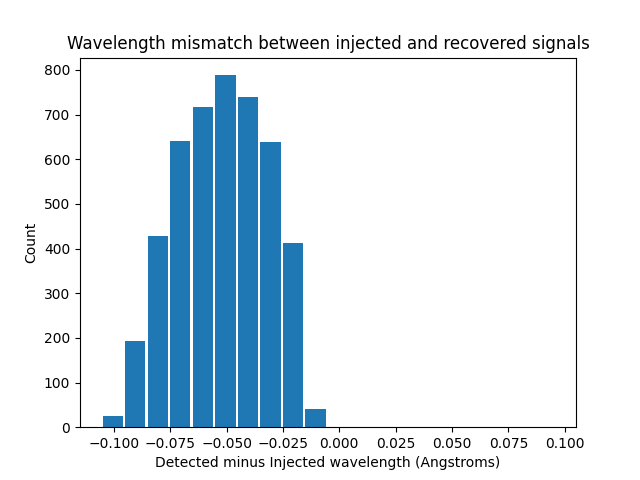

In [185]:
# I don't think we need to show this but here's a fun histogram.
plt.figure(4)
plt.clf()
plt.hist(detected_t['detected_wavelength']-detected_t['injected_wavelength'],bins=np.arange(-.105,.105,.01),width=.009)
plt.title('Wavelength mismatch between injected and recovered signals')
plt.xlabel('Detected minus Injected wavelength (Angstroms)')
plt.ylabel('Count')
plt.show()